In [11]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import cv2
%matplotlib inline
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

## Referências

https://mathworld.wolfram.com/Convolution.html

https://en.wikipedia.org/wiki/Convolution

## convolução em 1D

In [12]:
t = np.linspace(0, 20, 200)

In [13]:
y1 = np.sin(2*t)

In [14]:
y2 = signal.sawtooth(2 * np.pi * 80 * t, 0.5)

In [15]:
y3 = stats.norm.pdf(t, 10, 1)

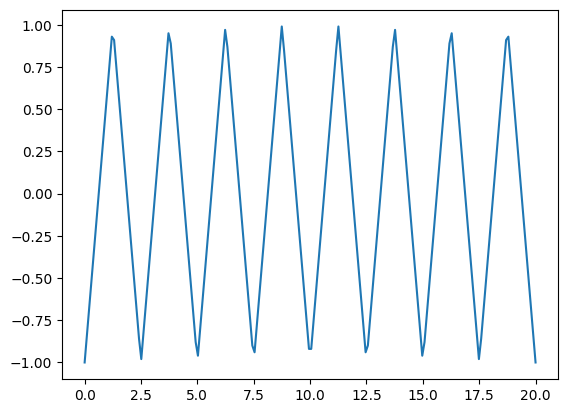

In [16]:
plt.plot(t, y2)

In [17]:
def plot_conv_functions(centro):
    plt.clf()  # Clear the current figure
    y3 = 1.2*stats.norm.pdf(t, centro, 0.5)
    plt.plot(t, y3)
    plt.plot(t, y2)
    plt.show()  # Explicitly show the plot

In [18]:
interact(plot_conv_functions, centro=(0, 20, 0.5))

interactive(children=(FloatSlider(value=10.0, description='centro', max=20.0, step=0.5), Output()), _dom_class…

<function __main__.plot_conv_functions(centro)>

In [19]:
def conv1d(sinal, filtro):
    out = np.zeros((sinal.shape[0] - filtro.shape[0]))
    for i in range(sinal.shape[0] - filtro.shape[0]):
        out[i] = (sinal[i:i+filtro.shape[0]]*filtro).sum()
    return out

In [20]:
filtro = np.array([-3,-2,-1,1,2,3])

In [21]:
r = conv1d(y2, filtro)

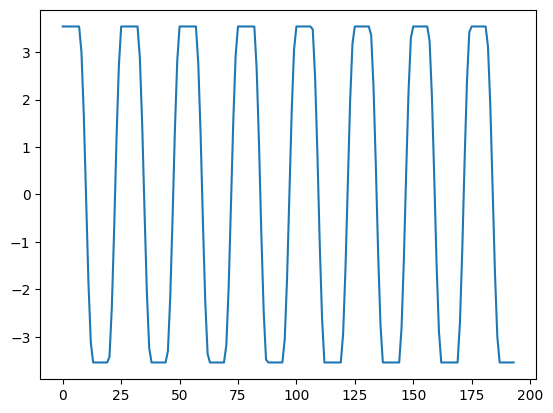

In [22]:
plt.plot(r)

## convolução em 2D

In [23]:
def processImage(image):
    image = cv2.imread(image)
    image = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
    return image

In [24]:
def convolve2D(image, kernel, padding=0, strides=1):
    kernel = np.flipud(np.fliplr(kernel))

    # Gather Shapes of Kernel + Image + Padding
    xKernShape = kernel.shape[0]
    yKernShape = kernel.shape[1]
    xImgShape = image.shape[0]
    yImgShape = image.shape[0]

    # Shape of Output Convolution
    xOutput = int(((xImgShape - xKernShape + 2 * padding) / strides) + 1)
    yOutput = int(((yImgShape - yKernShape + 2 * padding) / strides) + 1)
    output = np.zeros((xOutput, yOutput))

    # Apply Equal Padding to All Sides
    if padding != 0:
        imagePadded = np.zeros((image.shape[0] + padding*2, image.shape[1] + padding*2))
        imagePadded[int(padding):int(-1 * padding), int(padding):int(-1 * padding)] = image
    else:
        imagePadded = image

    # Iterate through image
    for y in range(image.shape[1]):
        # Exit Convolution
        if y > image.shape[1] - yKernShape:
            break
        # Only Convolve if y has gone down by the specified Strides
        if y % strides == 0:
            for x in range(image.shape[0]):
                # Go to next row once kernel is out of bounds
                if x > image.shape[0] - xKernShape:
                    break
                try:
                    # Only Convolve if x has moved by the specified Strides
                    if x % strides == 0:
                        output[x, y] = (kernel * imagePadded[x: x + xKernShape, y: y + yKernShape]).sum()
                except:
                    break

    return output

In [25]:
#  out = cv2.filter2D(image, -1, kernel)

In [29]:
!curl -o Image.png https://i.ibb.co/HD1ySmz2/predios.png

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  4  944k    4 44671    0     0  64855      0  0:00:14 --:--:--  0:00:14 64928
100  944k  100  944k    0     0   696k      0  0:00:01  0:00:01 --:--:--  696k


[[255 255 251 ... 179 179 179]
 [255 255 251 ... 166 166 166]
 [255 255 251 ... 166 167 167]
 ...
 [255 255 254 ... 147 143 140]
 [254 253 254 ... 255 255 255]
 [254 253 254 ... 255 255 255]]


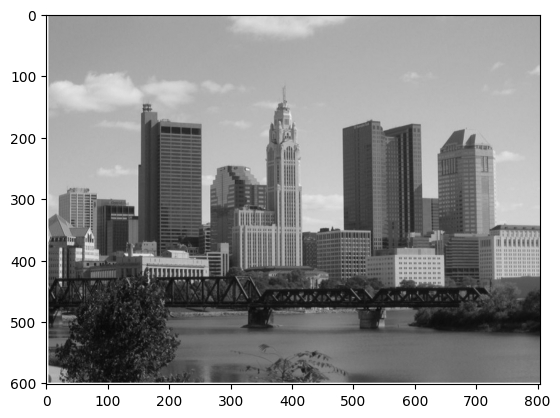

In [32]:
image = processImage('Image.png')
print(image)
plt.imshow(image, cmap='gray')

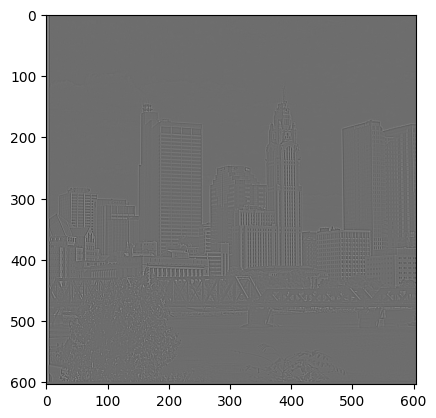

In [33]:
# Edge Detection Kernel
kernel = np.array([[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]])

# Convolve and Save Output
output = convolve2D(image, kernel, padding=2)
cv2.imwrite('2DConvolved.jpg', output)
plt.imshow(output, cmap='gray')

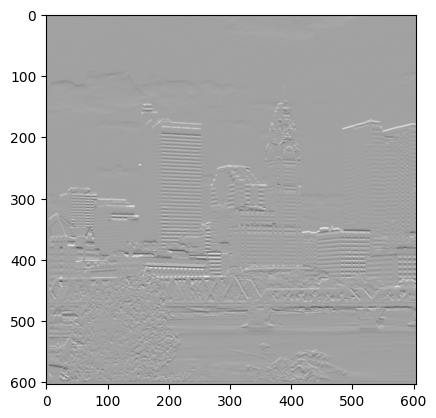

In [34]:
# Edge Detection Kernel
kernel = np.array([[-1, -2, -1],
                   [0, 0, 0],
                   [1, 2, 1]])

# Convolve and Save Output
output = convolve2D(image, kernel, padding=2)
cv2.imwrite('2DConvolved2.jpg', output)
plt.imshow(output, cmap='gray')

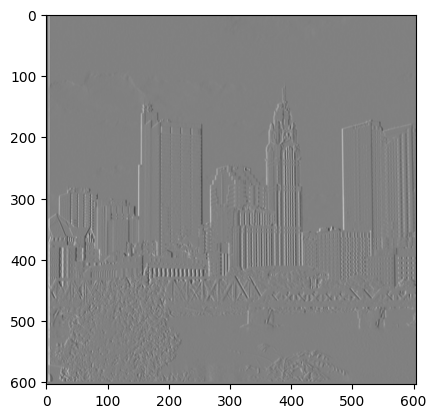

In [35]:
# Edge Detection Kernel
kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

# Convolve and Save Output
output = convolve2D(image, kernel, padding=2)
cv2.imwrite('2DConvolved2.jpg', output)
plt.imshow(output, cmap='gray')

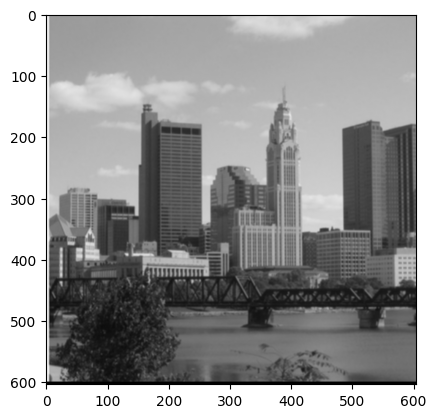

In [36]:
# Edge Detection Kernel
kernel = np.array([[8, 8, 8],
                   [8, 8, 8],
                   [8, 8, 8]])

# Convolve and Save Output
output = convolve2D(image, kernel, padding=2)
cv2.imwrite('2DConvolved2.jpg', output)
plt.imshow(output, cmap='gray')